# FracAtlas model comparison

This notebook trains three independent image classifiers on the same FracAtlas split. The candidate used by the FractureCare API is selected on the validation split by **fracture average recall** (the average recall of ONE_FRACTURE and MULTIPLE_FRACTURES), with all-class average F1 as the tie-breaker. The selected model is then evaluated once on the untouched test split.

Why each model is included

Custom CNN - A transparent, lightweight baseline that can be changed easily and establishes a reference point.

MobileNetV2 - An efficient transfer-learning model suited to limited data and practical CPU inference.

EfficientNetB0 - A stronger accuracy/efficiency candidate whose compound scaling often performs well on image classification.


In [1]:
from pathlib import Path
import json
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "1")
import math
import sys
import gc

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

# Allow TensorFlow to grow GPU memory as needed instead of reserving a fixed block.
_available_gpus = tf.config.list_physical_devices('GPU')
for _gpu in _available_gpus:
    try:
        tf.config.experimental.set_memory_growth(_gpu, True)
    except RuntimeError:
        pass
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
SERVICE_DIR = next(path for path in candidates if (path / 'app').is_dir() and (path / 'requirements.txt').exists())
PROJECT_DIR = SERVICE_DIR.parent
sys.path.insert(0, str(SERVICE_DIR))
from app.config import ARTIFACT_DIR, DATASET_CSV, IMAGE_DIR, IMAGE_SIZE, SEED
from app.data import load_manifest
from app.labels import CLASS_NAMES
from app.metrics import SELECTION_METRIC, calculate_classification_metrics, select_best_result
from app.model import MODEL_NAMES, build_model, build_transfer_model

MODEL_EPOCHS = 5
BATCH_SIZE = 8
USE_IMAGENET_WEIGHTS = True
MODEL_DIR = ARTIFACT_DIR / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
tf.keras.utils.set_random_seed(SEED)
print('TensorFlow:', tf.__version__)
print('Dataset:', DATASET_CSV)

I0000 00:00:1788042229.516944     385 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788042232.102273     385 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
Dataset: /mnt/c/Users/Rushd/OneDrive - wslqd/Documents/Uni Documents/ICBT/Development Project Final Year/Final Documents/fracturecare-prototype/Dataset/FracAtlas/dataset.csv


W0000 00:00:1788042233.775804     385 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [2]:
frame = load_manifest()
train, holdout = train_test_split(frame, test_size=0.2, random_state=SEED, stratify=frame['label_index'])
validation, test = train_test_split(holdout, test_size=0.5, random_state=SEED, stratify=holdout['label_index'])
train, validation, test = [part.reset_index(drop=True) for part in (train, validation, test)]
print(f'Images: {len(frame):,} | train: {len(train):,} | validation: {len(validation):,} | test: {len(test):,}')
display(frame['label'].value_counts().reindex(CLASS_NAMES).rename('count').to_frame())

W0000 00:00:1788042260.459615     385 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
E0000 00:00:1788042295.356935     385 jpeg_mem.cc:331] Premature end of JPEG data. Stopped at line 414/454
W0000 00:00:1788042295.356981     385 local_rendezvous.cc:412] Local rendezvous is aborting with status: INVALID_ARGUMENT: jpeg::Uncompress failed. Invalid JPEG data or crop window.
E0000 00:00:1788042295.361946     385 jpeg_mem.cc:331] Premature end of JPEG data. Stopped at line 398/454
W0000 00:00:1788042295.361997     385 local_rendezvous.cc:412] Local rendezvous is aborting with status: INVALID_ARGUMENT: jpeg::Uncompress failed. Invalid JPEG data or crop window.
E0000 00:00:1788042295.367867     385 jpeg_mem.cc:331] Premature end of JPEG data. Stopped at line 446/454
E0000 00:00:1788042295.427829     385 jpeg_mem.cc:331] Premature end of JPEG data

Images: 4,024 | train: 3,219 | validation: 402 | test: 403


/tmp/ipykernel_385/1086553765.py:1: RuntimeWarning: Skipped 59 unreadable image file(s) from the manifest.
  frame = load_manifest()


,count
label,
NO_FRACTURE,3307
ONE_FRACTURE,546
MULTIPLE_FRACTURES,171


In [3]:
def make_dataset(dataframe, shuffle=False):
    paths = dataframe['path'].to_numpy()
    labels = dataframe['label_index'].to_numpy(dtype=np.int32)
    def load(path, label):
        image = tf.io.read_file(path)
        image = tf.io.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, IMAGE_SIZE)
        return image, label
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        dataset = dataset.shuffle(len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    dataset = dataset.map(load, num_parallel_calls=1)
    dataset = dataset.apply(tf.data.experimental.ignore_errors())
    return dataset.batch(BATCH_SIZE).prefetch(1)

train_dataset = make_dataset(train, shuffle=True).repeat()
validation_dataset = make_dataset(validation).repeat()
validation_eval_dataset = make_dataset(validation)
test_dataset = make_dataset(test)
TRAIN_STEPS = math.ceil(len(train) / BATCH_SIZE)
VALIDATION_STEPS = math.ceil(len(validation) / BATCH_SIZE)
weights = compute_class_weight('balanced', classes=np.arange(len(CLASS_NAMES)), y=train['label_index'].to_numpy())
class_weights = {index: float(weight) for index, weight in enumerate(weights)}
print('Class weights:', class_weights)

Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.
Class weights: {0: 0.4056710775047259, 1: 2.4553775743707096, 2: 7.8321167883211675}


## Train each model separately

Each loop iteration creates a fresh model, trains it from the same training split, selects its best validation checkpoint, and evaluates it only once on the held-out test split. ImageNet weights are used only by the two transfer-learning models.

In [4]:
def create_model(model_name):
    if model_name == 'custom_cnn':
        return build_model()
    weights = 'imagenet' if USE_IMAGENET_WEIGHTS else None
    return build_transfer_model(model_name, weights=weights)

model_paths = {}
histories = {}
results = []

for model_name in MODEL_NAMES:
    print(f'\n===== Training {model_name} =====', flush=True)
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    model = create_model(model_name)
    path = MODEL_DIR / f'{model_name}.keras'
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(path, monitor='val_accuracy', save_best_only=True),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6),
    ]

    history = model.fit(train_dataset, validation_data=validation_dataset, epochs=MODEL_EPOCHS, steps_per_epoch=TRAIN_STEPS, validation_steps=VALIDATION_STEPS, class_weight=class_weights, callbacks=callbacks, shuffle=False)
    histories[model_name] = history.history
    model_paths[model_name] = path
    del model
    gc.collect()
    tf.keras.backend.clear_session()


===== Training custom_cnn =====
Epoch 1/5


E0000 00:00:1788042300.227595     385 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/fracatlas_fracture_classifier_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


403/403 ━━━━━━━━━━━━━━━━━━━━ 37s 78ms/step - accuracy: 0.4358 - loss: 1.1004 - val_accuracy: 0.8234 - val_loss: 0.6898 - learning_rate: 0.0010
Epoch 2/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 31s 78ms/step - accuracy: 0.5275 - loss: 1.0295 - val_accuracy: 0.0871 - val_loss: 1.7833 - learning_rate: 0.0010
Epoch 3/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 31s 77ms/step - accuracy: 0.5545 - loss: 1.0285 - val_accuracy: 0.8184 - val_loss: 0.7394 - learning_rate: 0.0010

===== Training mobilenetv2 =====
Epoch 1/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 35s 80ms/step - accuracy: 0.5219 - loss: 1.0957 - val_accuracy: 0.8383 - val_loss: 0.5587 - learning_rate: 0.0010
Epoch 2/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 31s 77ms/step - accuracy: 0.6340 - loss: 0.8522 - val_accuracy: 0.7438 - val_loss: 0.5933 - learning_rate: 0.0010
Epoch 3/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.6577 - loss: 0.7780 - val_accuracy: 0.8035 - val_loss: 0.5323 - learning_rate: 0.0010
Epoch 4/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 31s 76ms/step - acc

In [5]:
for model_name, path in model_paths.items():
    model = tf.keras.models.load_model(path)
    probabilities = model.predict(validation_eval_dataset, verbose=0)
    predicted = probabilities.argmax(axis=1)
    actual = np.concatenate([labels.numpy() for _, labels in validation_eval_dataset], axis=0)
    metrics = calculate_classification_metrics(actual, predicted)
    results.append({'model': model_name, **metrics})
    print(f'\n{model_name}')
    print(json.dumps(metrics, indent=2))

results_df = pd.DataFrame(results).sort_values(
    ['average_recall', 'average_f1', 'average_precision', 'accuracy'], ascending=False
).reset_index(drop=True)
display(results_df.style.format({c: '{:.4f}' for c in results_df.columns if c != 'model'}))


/home/rushd/fracturecare-ai-venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



custom_cnn
{
  "accuracy": 0.8233830845771144,
  "average_precision": 0.27446102819237145,
  "average_recall": 0.3333333333333333,
  "average_f1": 0.3010459299681673
}


/home/rushd/fracturecare-ai-venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



mobilenetv2
{
  "accuracy": 0.8383084577114428,
  "average_precision": 0.6023589675944246,
  "average_recall": 0.5584406751399228,
  "average_f1": 0.5574094325539413
}


/home/rushd/fracturecare-ai-venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



efficientnetb0
{
  "accuracy": 0.8407960199004975,
  "average_precision": 0.6254656306384959,
  "average_recall": 0.6803430110994828,
  "average_f1": 0.6457410881801127
}


,model,accuracy,average_precision,average_recall,average_f1
0,efficientnetb0,0.8408,0.6255,0.6803,0.6457
1,mobilenetv2,0.8383,0.6024,0.5584,0.5574
2,custom_cnn,0.8234,0.2745,0.3333,0.3010


## Comparison Charts

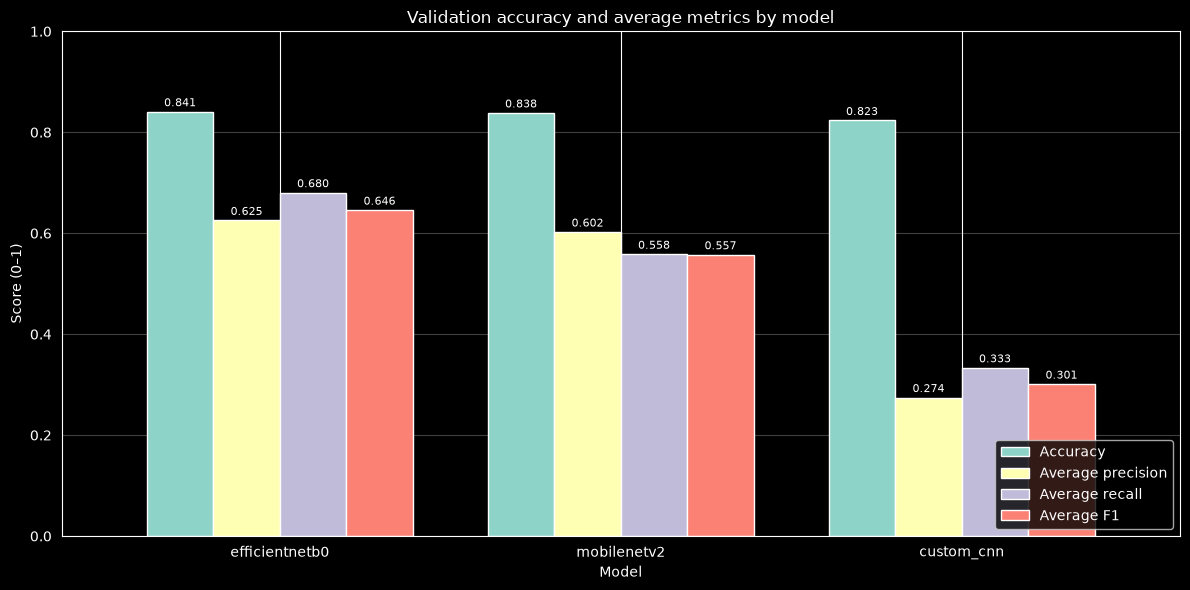

Saved: /mnt/c/Users/Rushd/OneDrive - wslqd/Documents/Uni Documents/ICBT/Development Project Final Year/Final Documents/fracturecare-prototype/ai-service/artifacts/model_metric_comparison.png


In [6]:
# Export the four report metrics only.
metric_columns = {'Accuracy':'accuracy', 'Average precision':'average_precision',
                  'Average recall':'average_recall', 'Average F1':'average_f1'}
metric_frame = results_df.set_index('model')[[c for c in metric_columns.values()]]
metric_frame = metric_frame.rename(columns={v:k for k,v in metric_columns.items()})
ax = metric_frame.plot(kind='bar', figsize=(12,6), ylim=(0,1), width=.78)
ax.set_title('Validation accuracy and average metrics by model')
ax.set_xlabel('Model'); ax.set_ylabel('Score (0–1)')
ax.legend(loc='lower right'); ax.grid(axis='y', alpha=.25)
for c in ax.containers: ax.bar_label(c, fmt='%.3f', padding=2, fontsize=8)
plt.xticks(rotation=0); plt.tight_layout()
comparison_plot_path = ARTIFACT_DIR / 'model_metric_comparison.png'
plt.savefig(comparison_plot_path, dpi=220, bbox_inches='tight')
plt.show(); print('Saved:', comparison_plot_path)


In [7]:
best_result = select_best_result(results)
best_name = best_result['model']
best_model = tf.keras.models.load_model(model_paths[best_name])
final_probabilities = best_model.predict(test_dataset, verbose=0)
final_predicted = final_probabilities.argmax(axis=1)
final_actual = np.concatenate([labels.numpy() for _, labels in test_dataset], axis=0)
final_test_metrics = calculate_classification_metrics(final_actual, final_predicted)
print('Final test-set metrics:'); print(json.dumps(final_test_metrics, indent=2))
best_model.save(ARTIFACT_DIR / 'fracture_classifier.keras')
results_df.to_csv(ARTIFACT_DIR / 'model_comparison.csv', index=False)
test.to_csv(ARTIFACT_DIR / 'test_manifest.csv', index=False)
metadata = {'modelVersion': f'fracatlas-{best_name}-1.0.0', 'selectedModel': best_name,
    'classes': list(CLASS_NAMES), 'imageSize': list(IMAGE_SIZE), 'datasetCsv': str(DATASET_CSV),
    'trainCount': int(len(train)), 'validationCount': int(len(validation)), 'testCount': int(len(test)),
    'selectionMetric': SELECTION_METRIC, 'comparison': results_df.to_dict(orient='records'),
    'finalTestMetrics': final_test_metrics}
(ARTIFACT_DIR / 'model_metadata.json').write_text(json.dumps(metadata, indent=2, default=float), encoding='utf-8')
print(f'Selected {best_name} using {SELECTION_METRIC} and saved it to {ARTIFACT_DIR / "fracture_classifier.keras"}')
display(results_df)


/home/rushd/fracturecare-ai-venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Final test-set metrics:
{
  "accuracy": 0.7915632754342432,
  "average_precision": 0.5284865307284439,
  "average_recall": 0.5761797825419649,
  "average_f1": 0.5436342183186867
}
Selected efficientnetb0 using average_recall and saved it to /mnt/c/Users/Rushd/OneDrive - wslqd/Documents/Uni Documents/ICBT/Development Project Final Year/Final Documents/fracturecare-prototype/ai-service/artifacts/fracture_classifier.keras


,model,accuracy,average_precision,average_recall,average_f1
0,efficientnetb0,0.840796,0.625466,0.680343,0.645741
1,mobilenetv2,0.838308,0.602359,0.558441,0.557409
2,custom_cnn,0.823383,0.274461,0.333333,0.301046
